Copyright 2025 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '..')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import scipy.special

import cpadenn
from cpadenn import Layers, Models, Utils

2026-03-17 17:04:54.138755: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 17:04:54.140355: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 17:04:54.148587: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 17:04:54.173659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773763494.215414 3237835 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773763494.22

In [2]:
def n_thirring1d(mu, beta=1.0, L=8.0, m=2.0):

    mu = np.complex128(mu)

    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)
    
    res = I1**L * np.sinh(L*mu)
    res = res / (I1**L * np.cosh(L*mu) + I0**L * np.cosh(mtilde))

    return res

In [3]:
def n_thirring1d_sing(beta=1.0, L=8.0, m=2.0):
    
    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)

    res = (1.0/L) * np.acosh(   np.complex128(- I0**L / I1**L * np.cosh(mtilde))   )
    
    res_arr = res + np.array([1.0j*2.0*np.pi*n/L for n in range(-5,5)])
    res_arr = np.append(res_arr, -res_arr)

    return res_arr

Text(0.5, 0, '$Re[\\mu]$')

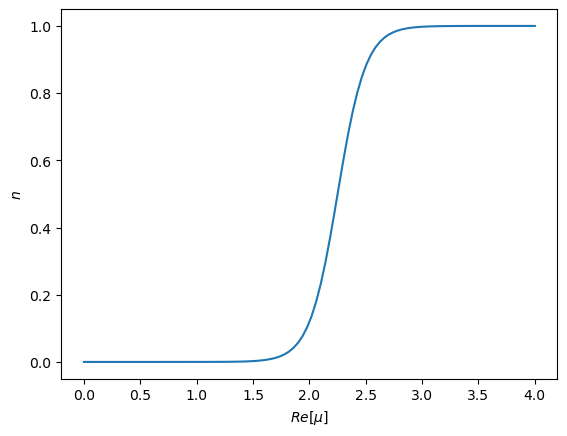

In [4]:
mymu = np.linspace(0., 4., 100)
plt.plot(mymu, n_thirring1d(mymu).real)
plt.ylabel('$n$')
plt.xlabel('$Re[\mu]$')

In [5]:
n_thirring1d_sing()

array([ 2.25019782-3.53429174j,  2.25019782-2.74889357j,
        2.25019782-1.96349541j,  2.25019782-1.17809725j,
        2.25019782-0.39269908j,  2.25019782+0.39269908j,
        2.25019782+1.17809725j,  2.25019782+1.96349541j,
        2.25019782+2.74889357j,  2.25019782+3.53429174j,
       -2.25019782+3.53429174j, -2.25019782+2.74889357j,
       -2.25019782+1.96349541j, -2.25019782+1.17809725j,
       -2.25019782+0.39269908j, -2.25019782-0.39269908j,
       -2.25019782-1.17809725j, -2.25019782-1.96349541j,
       -2.25019782-2.74889357j, -2.25019782-3.53429174j])

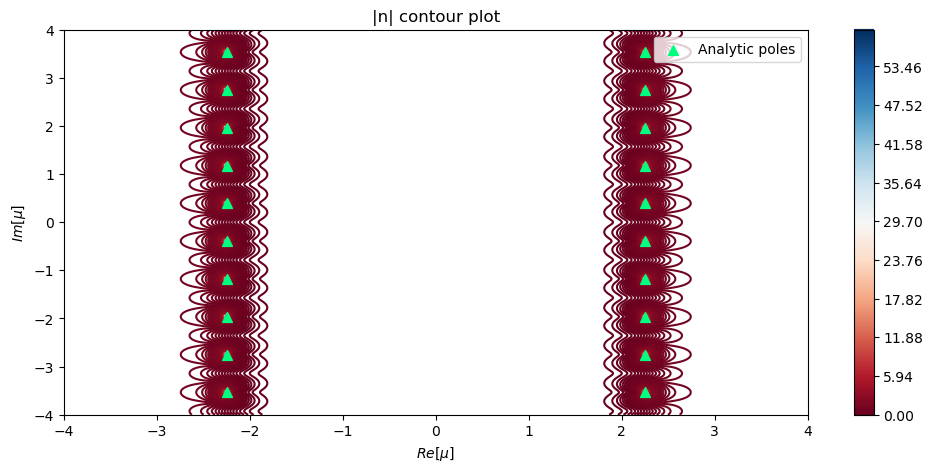

In [6]:
pts = 500
xg = np.linspace(-4, 4, pts)
yg = np.linspace(-4, 4, pts)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1.0j*Yg
out = n_thirring1d(Zg)

real_out = out.reshape(Xg.shape)
imag_out = out.imag.reshape(Yg.shape)
abs_out = np.abs(real_out + 1.0j * imag_out)

analytic_sings = n_thirring1d_sing()

plt.figure(figsize=(12, 5))
plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
#plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
plt.colorbar()
plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$Im[\mu]$')
plt.title('|n| contour plot')
plt.legend()

Text(0.5, 1.0, 'Test data')

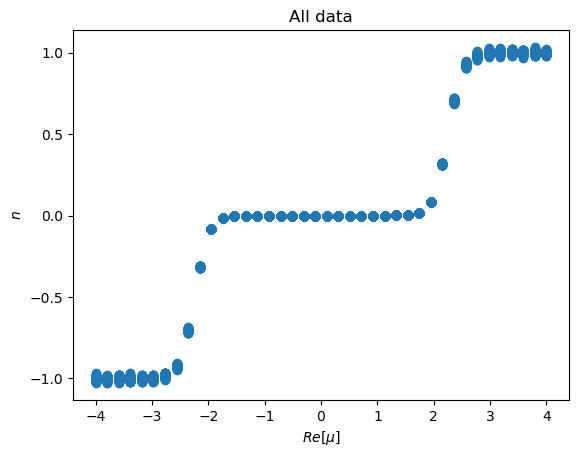

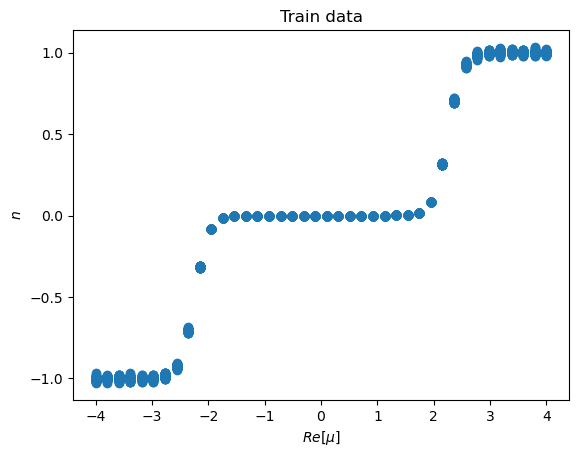

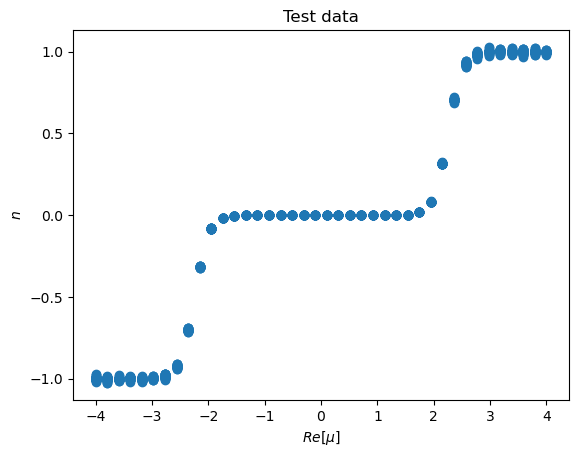

In [7]:
epsilon = 1.0e-2

mu_ = np.linspace(-4.0,4.0,40)
n_ = n_thirring1d(mu_)
dn_ = np.abs(n_) * epsilon

mu_sampled = mu_ 
n_sampled = n_ + dn_*np.random.randn(dn_.size)

for n in np.arange(100):
    mu_sampled = np.append(mu_sampled, mu_)
    n_sampled = np.append(n_sampled, n_ + dn_*np.random.randn(dn_.size))
    
X = np.transpose(np.stack([np.real(mu_sampled), np.imag(mu_sampled)]))
Y = np.transpose(np.stack([np.real(n_sampled), np.imag(n_sampled)]))

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('All data')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

plt.figure()
plt.plot(X_train[:,0], Y_train[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Train data')

plt.figure()
plt.plot(X_test[:,0], Y_test[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Test data')

In [8]:
modelNN_run1 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run1 = modelNN_run1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run1.summary())

Epoch 1/2000


2026-03-17 17:05:02.621328: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 2.3576 - val_loss: 0.6577
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5480 - val_loss: 0.3743
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3633 - val_loss: 0.2809
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2891 - val_loss: 0.2435
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2585 - val_loss: 0.2224
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2318 - val_loss: 0.2095
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2207 - val_loss: 0.1974
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2047 - val_loss: 0.1878
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1926 - val_loss: 0.1793
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1890 - val_loss: 0.1719
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1817 - val_loss: 0.1648
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0772 - val_loss: 0.0767
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0759 - val_loss: 0.0764
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0759 - val_loss: 0.0758
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0752 - val_loss: 0.0755
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0755 - val_loss: 0.0751
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0752 - val_loss: 0.0747
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0754 - val_loss: 0.0742
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0745 - val_loss: 0.0738
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0739 - val_loss: 0.0735
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0735 - val_loss: 0.0732
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0731 - val_loss: 0.0728
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0519 - val_loss: 0.0512
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0514 - val_loss: 0.0508
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0510 - val_loss: 0.0505
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0507 - val_loss: 0.0504
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0507 - val_loss: 0.0500
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0501 - val_loss: 0.0495
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0498 - val_loss: 0.0493
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0496 - val_loss: 0.0488
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0492 - val_loss: 0.0487
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0488 - val_loss: 0.0482
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0485 - val_loss: 0.0479
Epoch 146/2000
23/23 ━━━━━━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [9]:
modelNN_run2 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run2 = modelNN_run2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 8.4996 - val_loss: 3.7177
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.2452 - val_loss: 2.3067
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0083 - val_loss: 1.3745
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1476 - val_loss: 0.8322
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7203 - val_loss: 0.5634
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5182 - val_loss: 0.4029
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3672 - val_loss: 0.2956
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2701 - val_loss: 0.2288
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2138 - val_loss: 0.1920
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1794 - val_loss: 0.1712
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1661 - val_loss: 0.1597
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0846 - val_loss: 0.0850
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0845 - val_loss: 0.0847
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0844 - val_loss: 0.0845
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0841 - val_loss: 0.0842
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0840 - val_loss: 0.0840
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0837 - val_loss: 0.0838
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0834 - val_loss: 0.0835
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0832 - val_loss: 0.0833
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0828 - val_loss: 0.0831
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0827 - val_loss: 0.0828
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0826 - val_loss: 0.0826
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/s

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0685 - val_loss: 0.0683
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0681 - val_loss: 0.0680
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0680 - val_loss: 0.0678
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0678 - val_loss: 0.0676
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0676 - val_loss: 0.0674
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0673 - val_loss: 0.0672
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0671 - val_loss: 0.0670
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0668 - val_loss: 0.0668
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0667 - val_loss: 0.0666
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0666 - val_loss: 0.0664
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0663 - val_loss: 0.0662
Epoch 146/2000
23/23 ━━━━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0557 - val_loss: 0.0556
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0555 - val_loss: 0.0553
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0553 - val_loss: 0.0552
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0552 - val_loss: 0.0549
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0550 - val_loss: 0.0548
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0547 - val_loss: 0.0546
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0546 - val_loss: 0.0544
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0543 - val_loss: 0.0542
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0541 - val_loss: 0.0540
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0540 - val_loss: 0.0538
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0537 - val_loss: 0.0536
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0425 - val_loss: 0.0423
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0423 - val_loss: 0.0420
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0420 - val_loss: 0.0418
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0418 - val_loss: 0.0417
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0417 - val_loss: 0.0417
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0416 - val_loss: 0.0414
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0413 - val_loss: 0.0410
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0411 - val_loss: 0.0409
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0409 - val_loss: 0.0407
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0407 - val_loss: 0.0405
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0404 - val_loss: 0.0403
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [10]:
modelNN_baseline1 = cpadenn.Models.BaselineModel1(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline1 = modelNN_baseline1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline1.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 16.4809 - val_loss: 11.6905
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.4004 - val_loss: 7.3352
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.5916 - val_loss: 4.8346
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.3759 - val_loss: 3.4868
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.2053 - val_loss: 2.7257
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5668 - val_loss: 2.2512
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.1355 - val_loss: 1.9303
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8690 - val_loss: 1.7081
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6680 - val_loss: 1.5428
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4934 - val_loss: 1.4179
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3707 - val_loss: 1.3142
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1314 - val_loss: 0.1325
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1299 - val_loss: 0.1316
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1288 - val_loss: 0.1307
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1280 - val_loss: 0.1298
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1280 - val_loss: 0.1289
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1265 - val_loss: 0.1280
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1253 - val_loss: 0.1271
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1255 - val_loss: 0.1263
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1246 - val_loss: 0.1254
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1234 - val_loss: 0.1246
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1222 - val_loss: 0.1237
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0971 - val_loss: 0.0978
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0968 - val_loss: 0.0976
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0966 - val_loss: 0.0973
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0963 - val_loss: 0.0971
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0962 - val_loss: 0.0969
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0957 - val_loss: 0.0966
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0961 - val_loss: 0.0964
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0954 - val_loss: 0.0961
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0952 - val_loss: 0.0959
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0953 - val_loss: 0.0957
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0947 - val_loss: 0.0954
Epoch 146/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0808 - val_loss: 0.0813
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0804 - val_loss: 0.0811
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0802 - val_loss: 0.0808
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0799 - val_loss: 0.0805
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0798 - val_loss: 0.0803
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0795 - val_loss: 0.0800
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0792 - val_loss: 0.0797
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0795 - val_loss: 0.0795
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0785 - val_loss: 0.0792
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0783 - val_loss: 0.0790
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0786 - val_loss: 0.0787
Epoch 213/2000
23/23 ━━━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0632 - val_loss: 0.0632
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0627 - val_loss: 0.0630
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0625 - val_loss: 0.0627
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0622 - val_loss: 0.0624
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0619 - val_loss: 0.0623
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0616 - val_loss: 0.0620
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0613 - val_loss: 0.0617
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0612 - val_loss: 0.0615
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0607 - val_loss: 0.0612
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0608 - val_loss: 0.0609
Epoch 279/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0604 - val_loss: 0.0606
Epoch 280/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

...

 Total params: 344 (1.35 KB)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 230 (924.00 B)

None


In [11]:
modelNN_baseline2 = cpadenn.Models.BaselineModel2(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline2 = modelNN_baseline2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 2.4469 - val_loss: 0.8072
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6879 - val_loss: 0.4946
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4837 - val_loss: 0.4059
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3958 - val_loss: 0.3441
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3398 - val_loss: 0.3020
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3028 - val_loss: 0.2703
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2685 - val_loss: 0.2461
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2448 - val_loss: 0.2273
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2252 - val_loss: 0.2130
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2116 - val_loss: 0.2027
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2013 - val_loss: 0.1949
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1256 - val_loss: 0.1261
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1253 - val_loss: 0.1257
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1248 - val_loss: 0.1253
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1244 - val_loss: 0.1249
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1239 - val_loss: 0.1245
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1239 - val_loss: 0.1242
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1230 - val_loss: 0.1238
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1227 - val_loss: 0.1234
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1230 - val_loss: 0.1231
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1224 - val_loss: 0.1227
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1224 - val_loss: 0.1224
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1008 - val_loss: 0.1009
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1002 - val_loss: 0.1005
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0997 - val_loss: 0.1001
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0996 - val_loss: 0.0997
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0992 - val_loss: 0.0993
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0988 - val_loss: 0.0989
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0984 - val_loss: 0.0985
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0982 - val_loss: 0.0982
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0977 - val_loss: 0.0978
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0971 - val_loss: 0.0974
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0968 - val_loss: 0.0970
Epoch 146/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0756 - val_loss: 0.0758
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0754 - val_loss: 0.0754
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0750 - val_loss: 0.0751
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0750 - val_loss: 0.0747
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0744 - val_loss: 0.0744
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0743 - val_loss: 0.0740
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0735 - val_loss: 0.0737
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0733 - val_loss: 0.0733
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0732 - val_loss: 0.0731
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0729 - val_loss: 0.0726
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0721 - val_loss: 0.0725
Epoch 213/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0533 - val_loss: 0.0536
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0532 - val_loss: 0.0534
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0529 - val_loss: 0.0531
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0526 - val_loss: 0.0529
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0524 - val_loss: 0.0526
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0524 - val_loss: 0.0525
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0520 - val_loss: 0.0520
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0518 - val_loss: 0.0517
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0513 - val_loss: 0.0516
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0511 - val_loss: 0.0513
Epoch 279/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0509 - val_loss: 0.0512
Epoch 280/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

...

 Total params: 464 (1.82 KB)

 Trainable params: 154 (616.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 310 (1.21 KB)

None


Text(0, 0.5, 'Loss')

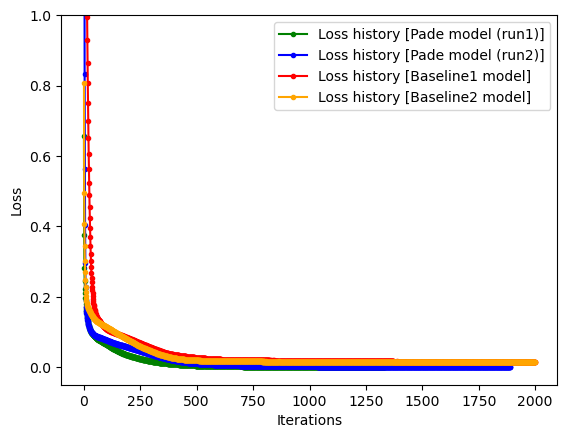

In [12]:
loss_NN_run1 = histNN_run1.history['val_loss']
loss_NN_run2 = histNN_run2.history['val_loss']
loss_NN_baseline1 = histNN_baseline1.history['val_loss']
loss_NN_baseline2 = histNN_baseline2.history['val_loss']

plt.plot(loss_NN_run1, label='Loss history [Pade model (run1)]', marker='.', color='green')
plt.plot(loss_NN_run2, label='Loss history [Pade model (run2)]', marker='.', color='blue')
plt.plot(loss_NN_baseline1, label='Loss history [Baseline1 model]', marker='.', color='red')
plt.plot(loss_NN_baseline2, label='Loss history [Baseline2 model]', marker='.', color='orange')
plt.legend()
plt.ylim([-0.05,1])
plt.xlabel('Iterations')
plt.ylabel('Loss')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


Text(0, 0.5, '$n$')

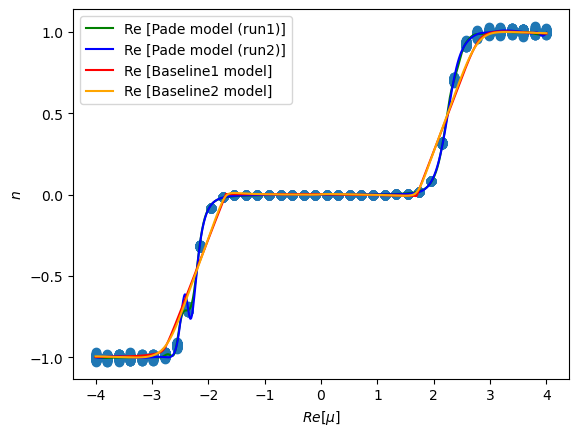

In [13]:
mu_pred = np.linspace(-4,4,1000)

X_pred = np.transpose(np.stack([np.real(mu_pred), np.imag(mu_pred)]))
Y_pred_NN_run1 = modelNN_run1.predict(X_pred)
Y_pred_NN_run2 = modelNN_run2.predict(X_pred)
Y_pred_NN_baseline1 = modelNN_baseline1.predict(X_pred)
Y_pred_NN_baseline2 = modelNN_baseline2.predict(X_pred)

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.plot(X_pred[:,0], Y_pred_NN_run1[:,0], color='green', label='Re [Pade model (run1)]')
plt.plot(X_pred[:,0], Y_pred_NN_run2[:,0], color='blue', label='Re [Pade model (run2)]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline1[:,0], color='red', label='Re [Baseline1 model]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline2[:,0], color='orange', label='Re [Baseline2 model]')
plt.legend()
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


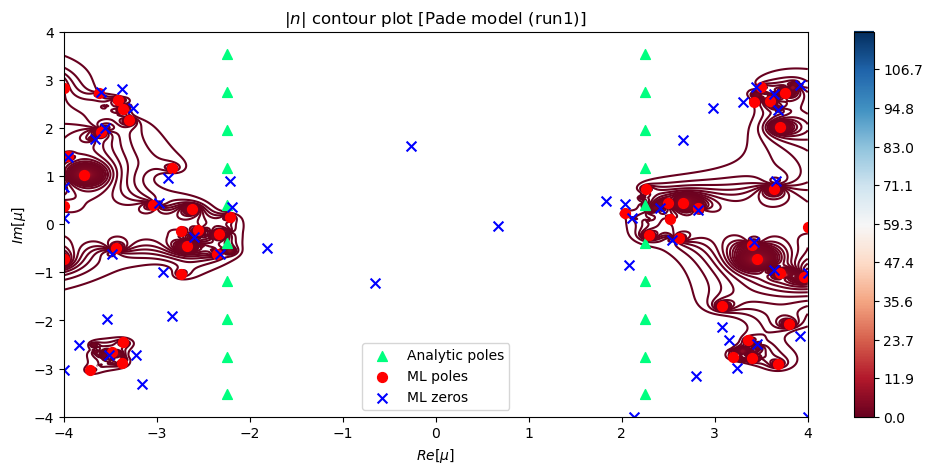

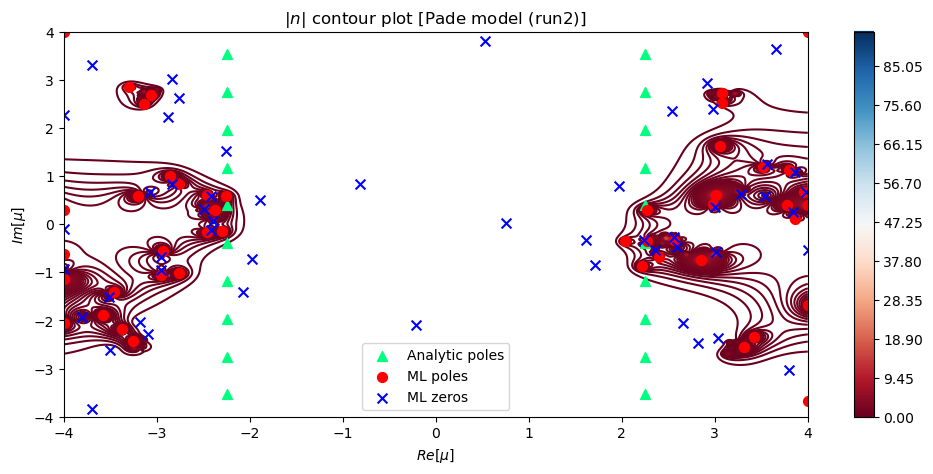

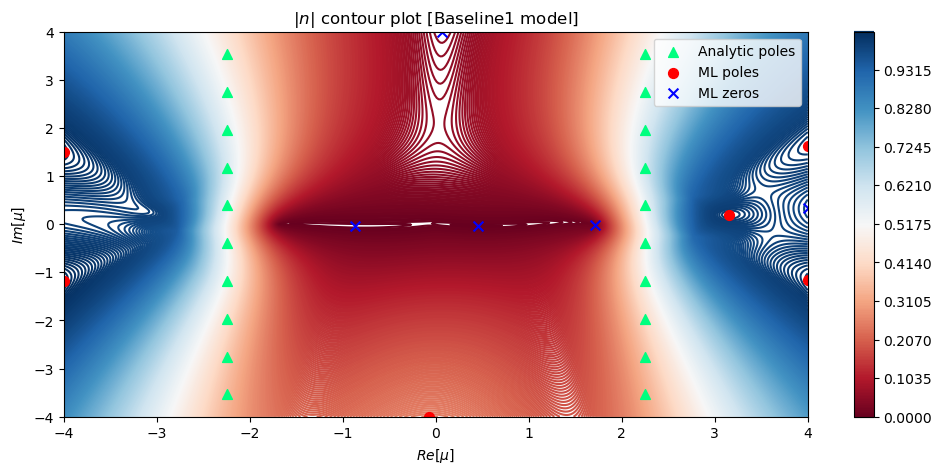

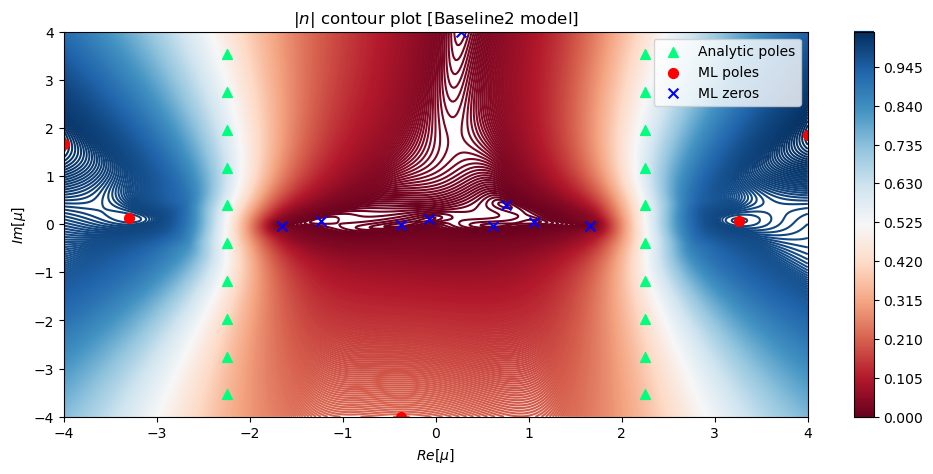

In [14]:
models = [modelNN_run1, modelNN_run2, modelNN_baseline1, modelNN_baseline2]
names = ['Pade model (run1)', 'Pade model (run2)', 'Baseline1 model', 'Baseline2 model']
for n in np.arange(4):
    pts = 400
    xg = np.linspace(-4, 4, pts)
    yg = np.linspace(-4, 4, pts)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = np.stack([Xg.ravel(), Yg.ravel()], axis=-1).astype(np.float32)
    out = models[n].predict(Zg)

    real_out = out[:, 0].reshape(Xg.shape)
    imag_out = out[:, 1].reshape(Yg.shape)
    abs_out = np.abs(real_out + 1.0j * imag_out)

    poles = cpadenn.Utils.FindLocMax(Xg, Yg, abs_out)
    zeros = cpadenn.Utils.FindLocMax(Xg, Yg, 1.0/abs_out)

    analytic_sings = n_thirring1d_sing()

    plt.figure(figsize=(12, 5))
    plt.contour(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    #plt.contourf(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    plt.colorbar()
    plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
    plt.scatter(poles[:,0], poles[:,1], color='red', marker='o', s=50, zorder=2, label='ML poles')
    plt.scatter(zeros[:,0], zeros[:,1], color='blue', marker='x', s=50, zorder=2, label='ML zeros')
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$Im[\mu]$')
    plt.title(f"$|n|$ contour plot [{names[n]}]")
    plt.legend()